In [138]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from sklearn.preprocessing import StandardScaler 
from sklearn.preprocessing import MinMaxScaler

In [139]:
df = pd.read_csv('HousingData.csv')

In [140]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


- CRIM - уровень преступности на душу населения в разбивке по городам
- ZN - доля жилых земель, разделенных на участки площадью более 25 000 кв.футов.
- INDUS - доля акров, не связанных с розничной торговлей, в городе.
- Фиктивная переменная CHAS - Charles River (1, если тракт граничит с рекой; 0 в противном случае)
- NOX - концентрация оксидов азота (частей на 10 миллионов)
- RM - среднее количество комнат в доме
- Age - доля домов, построенных владельцами до 1940 года.
- DIS - Взвешенные расстояния до пяти бостонских центров занятости
- RAD - индекс доступности радиальных автомагистралей
- TAX - полная стоимость недвижимости -ставка налога на 10 000 долларов США
- PTRATIO - Соотношение количества учеников и учителей в разбивке по городам
- B - 1000(Bk - 0,63)^2, где Bk - доля чернокожих в разбивке по городам
- LSTAT - процентный показатель низкого статуса населения
- MEDV - Средняя стоимость домов, занимаемых владельцами, в 1000 долларах

In [141]:
df.MEDV[df.MEDV>40] = np.nan

/var/folders/09/rfwddm1d2cs81ty3l9lsdcq80000gn/T/ipykernel_37595/664249113.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.MEDV[df.MEDV>40] = np.nan


In [142]:
df = df.dropna(axis = 'rows')

In [143]:
df.isna().any().any()

False

In [144]:
x = df.drop(columns= 'MEDV')

In [145]:
y = df.MEDV

In [146]:
scaller = MinMaxScaler()
x = scaller.fit_transform(x)

In [147]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2)

In [148]:
model = LinearRegression()

In [149]:
model.fit(x_train, y_train)

LinearRegression()

In [150]:
y_pred = model.predict(x_test)

In [151]:
y_pred

array([21.62472231, 30.27505932, 13.89199408, 27.16542927, 13.7278627 ,
       24.54828457, 30.60801919, 13.45213574, 31.35797067, 14.72061682,
       25.83499764, 25.7345938 , 32.50429181, 12.57441407, 12.73592939,
       13.34898169, 26.67870591, 13.46822023, 18.21069656, 16.40739059,
       13.55690067, 21.44492152, 19.03991864, 27.2983502 , 21.17844314,
       30.78565843, 21.35153815, 20.79631392, 14.58239859, 25.65356014,
       17.39429732, 21.31776885, 20.15662622, 11.59798012, 16.05718216,
       26.01814796, 15.18321088,  4.92408661, 16.66343499, 22.90653056,
       22.4713212 , 21.74500978, 20.8469024 , 28.92134595,  9.7683634 ,
       13.64807839, 26.93672184,  8.71248912, 29.54960876, 25.26117946,
       23.10188679, 25.8739949 , 25.81323061, 28.97119516, 15.0397963 ,
       16.87714362, 20.34609177, 18.3019545 , 17.74535088, 22.80133377,
       15.89824235, 20.51232498, 23.81338864, 18.16745376, 24.09320126,
       23.59446179,  5.77538292, 21.94775741, 24.67578251, 16.80

In [152]:
mean_absolute_error (y_test, y_pred)

2.5097521575965223

In [153]:
mean_squared_error(y_test, y_pred)

10.883243192881848

In [154]:
def errors(y_test, y_pred):
    ab = mean_absolute_error(y_test, y_pred)
    sq = mean_squared_error(y_test, y_pred)
    print (ab, sq)

In [155]:
errors(y_test, y_pred)

2.5097521575965223 10.883243192881848


In [156]:
model_new =  LinearRegression()

In [157]:
params = {
   'fit_intercept': [True, False],
    'copy_X': [True, False],
    'n_jobs': [True, False],
    'positive': [True, False]
}


In [158]:
gscv = GridSearchCV(estimator = model, param_grid= params, n_jobs = -1, cv = 5)

In [159]:
gscv.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=LinearRegression(), n_jobs=-1,
             param_grid={'copy_X': [True, False],
                         'fit_intercept': [True, False],
                         'n_jobs': [True, False], 'positive': [True, False]})

In [160]:
best_model = gscv.best_estimator_
best_model

LinearRegression(n_jobs=True)

In [161]:
y_pred_best = model.predict(x_test)

In [162]:
errors (y_test, y_pred_best)

2.5097521575965223 10.883243192881848


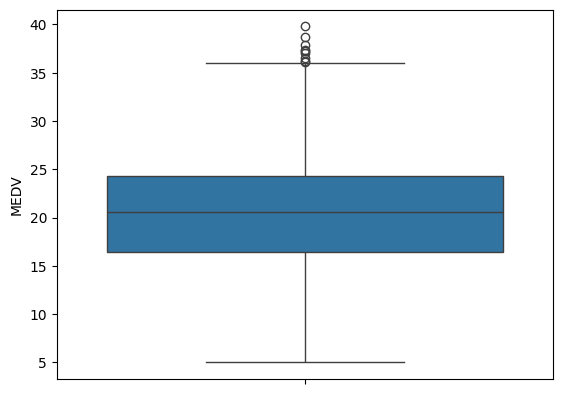

In [163]:
sns.boxplot(y)
plt.show()

In [164]:
y

0      24.0
1      21.6
2      34.7
3      33.4
5      28.7
       ... 
499    17.5
500    16.8
502    20.6
503    23.9
504    22.0
Name: MEDV, Length: 371, dtype: float64

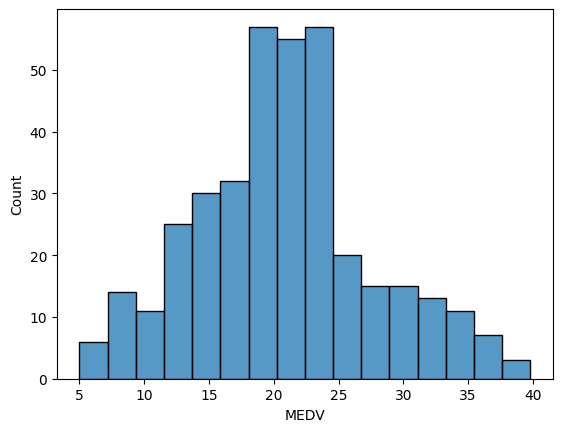

In [165]:
sns.histplot(y)
plt.show()

In [166]:
df.isna().any()

CRIM       False
ZN         False
INDUS      False
CHAS       False
NOX        False
RM         False
AGE        False
DIS        False
RAD        False
TAX        False
PTRATIO    False
B          False
LSTAT      False
MEDV       False
dtype: bool

In [167]:
def a (a, *b):
    print(a,b)

In [168]:
a(3,2,3)

3 (2, 3)
